In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Fourier Transform
Un segnale può essere rappresentato come una somma pesata di seni e coseni. Questa rappresentazione si chiama serie di Fourier. La trasformata di Fourier permette di descrivere funzioni non periodiche e di passare dal dominio del tempo a quello delle frequenze (o viceversa). 
La formula: $$F(\omega)= \int_{-\infty}^{+\infty}f(t) e^{-j 2\pi \omega t} dt$$

# DFT
Quando si passa all'elaborazione digitale si lavora con funzioni campionate. Consideriamo $f(t)$ campionata con N campioni equidistanti: chiamiamo $f[n]$ l'array che contiene i valori campionati. Possiamo considerare $f[n]$ una funzione discreta e finita con N campioni. Dobbiamo renderla periodica nell'intervallo [0, T].
La DFT permette di trasformare i campioni $f[n]$ in coefficienti $F[k]$ nel dominio delle frequenze.
La sua formula è la seguente:

$$F[k]= \sum_{n=0}^{N-1}f[n] e^{-j{{2\pi}\over N }kn}$$


## Costruzione del segnale
Andiamo a impostare i parametri temporali, costruiamo un asse dei tempi e una funziona formata dalla somma di sinusoidi


Sampling interval 0.01
Sampling frequency 100.0
Array size 300


Text(0, 0.5, 'y')

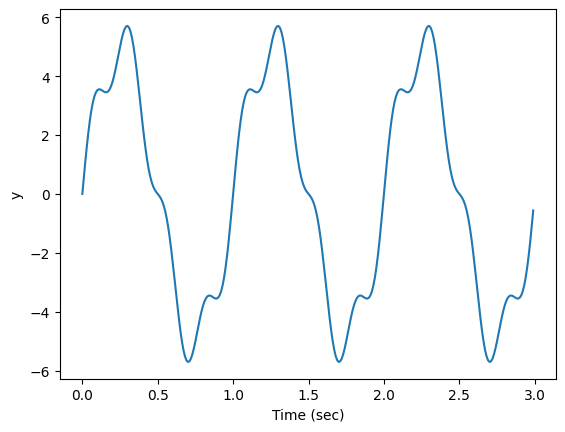

In [2]:
delta_s = 1./100 # intervallo di campionamento
f_s = 1./delta_s # Frequenza di campionamento in Hz
print("Sampling interval", delta_s)
print("Sampling frequency", f_s)

f = 1.0 # Frequenza base del segnale (1 Hz)
T = 3.0 # Durata totale dell'osservazione (3 secondi)

time = np.arange(0.0, T, delta_s)
N = time.size # numero dei campioni
print("Array size", N)

# COSTRUZIONE DI UNA FUNZIONE DISPARI (usando i seni)
y = 5 * np.sin(2 * np.pi * f * time) + 1 * np.sin(4 * 2 * np.pi * f * time)

# COSTRUZIONE DI UNA FUNZIONE PARI 
# y = 5 * np.cos(2 * np.pi * f * time) + 1 * np.cos(10 * 2 * np.pi * f * time) + 1 * np.cos(3 * 2 * np.pi * f * time)

# Plottiamo il risultato
plt.plot(time, y)
plt.xlabel("Time (sec)")
plt.ylabel("y")

### Calcolare la DFT

Usando la libreria ${\tt numpy}$, calcoleremo:
<ul>
    <li>la DFT</li>
    <li>il suo corrispondente vettore delle frequenze </li>
    <li>la DFT inversa (per tornare al segnale)</li>
</ul>


I valori nel risultato seguono il cosiddetto ordine "standard": se A = fft(a, n), allora A[0] contiene il termine a frequenza zero (la somma del segnale), che è sempre puramente reale per input reali. Successivamente, A[1:n/2] contiene i termini a frequenza positiva, e A[n/2+1:] contiene i termini a frequenza negativa, in ordine di frequenza negativa decrescente.

La funzione np.fft.fftfreq(n) restituisce un array che fornisce le frequenze degli elementi corrispondenti nell'output.

In [3]:
fft_y = np.fft.fft(y) # Calcola le ampiezze complesse per ogni frequenza
n = len(fft_y)
print(n)
freq = np.fft.fftfreq(n, 1/f_s)

# 0 frequency term
print("F[0]=",fft_y[0])

300
F[0]= (-9.95180269466372e-15+0j)


La funzione np.abs calcola il valore assoluto elemento per elemento. Per un input complesso, $a + ib$, il valore assoluto è <I> reale </I>: $\sqrt{ a^2 + b^2 }$.
    
    

### Plotting  DFT   
Il valore assoluto incorpora l'ampiezza (o magnitudo) di ciascuna componente in frequenza presente nel segnale.

(-9.95180269466372e-15+0j)


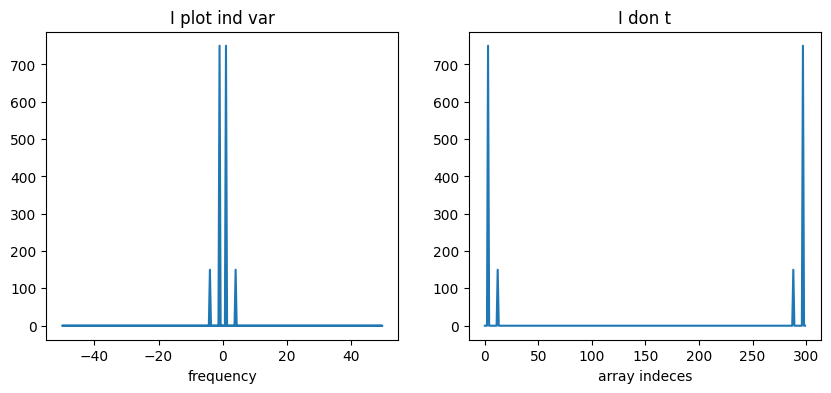

In [4]:
#primo grafico
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freq,np.abs(fft_y))
plt.xlabel('frequency')
plt.title("I plot ind var")

# secondo grafico
plt.subplot(1,2,2)
plt.plot(np.abs(fft_y))
plt.xlabel('array indeces')
plt.title('I don t')

print (fft_y[0])

## Componente Reale e Immaginaria

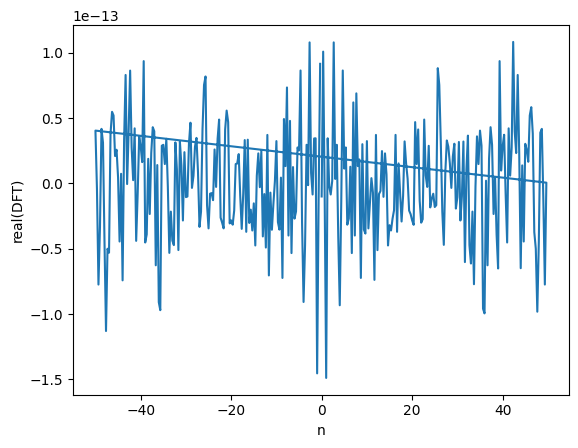

In [5]:
#real component
#coseno
R=np.real(fft_y)
plt.xlabel('n')
plt.ylabel("real(DFT)")
plt.plot(freq,R)

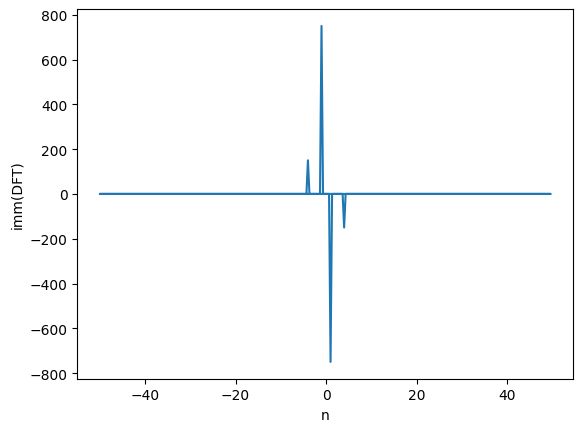

In [6]:
#imag component
#seno
Im=np.imag(fft_y)
plt.xlabel('n')
plt.ylabel("imm(DFT)")
plt.plot(freq,Im)

### Scambiare le due metà (semispazi)

Nota che le frequenze nella DFT e nel vettore `freq` vanno da zero a un numero positivo più grande, per poi saltare a un numero negativo in modulo grande e tornare verso lo zero. Possiamo scambiare queste parti in modo che la componente DC (frequenza zero) si trovi al centro del vettore, mantenendo così uno spettro bilatero (a due lati).

In [7]:
fft_y_shifted = np.fft.fftshift(fft_y)
freq_shifted = np.fft.fftshift(freq)

Text(0.5, 1.0, 'Imaginary part')

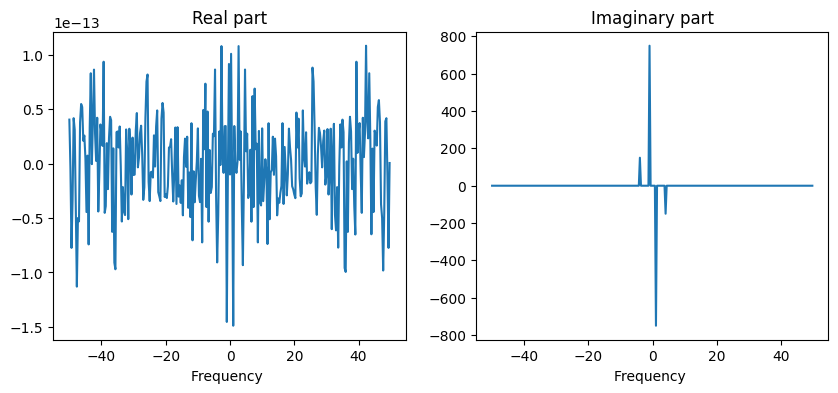

In [8]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freq_shifted, np.real(fft_y_shifted)) # non cambia
plt.xlabel("Frequency ")
plt.title("Real part")
plt.subplot(1,2,2)
plt.plot(freq_shifted, np.imag(fft_y_shifted)) # non cambia
plt.xlabel("Frequency ")
plt.title("Imaginary part")

# Ritorno al segnale

Text(0, 0.5, 'y')

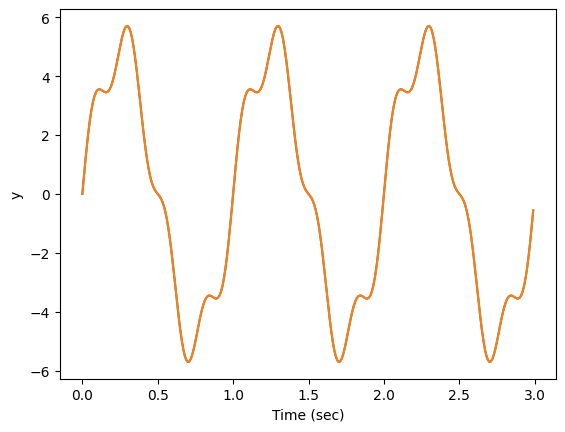

In [9]:
# inverse DFT
fft_y_shifted_back = np.fft.ifftshift(fft_y_shifted)

# guardare cosa succede se non shifto il segnale
#fft_y_shifted_back = np.fft.ifft(fft_y)

y_rec=np.fft.ifft(fft_y_shifted_back)
plt.plot(time, y_rec.real) 
plt.plot(time,y)
plt.xlabel("Time (sec)")
plt.ylabel("y")

## Parte 2: altro esempio

In [10]:
f_s = 512.0 # Hz
T=1.0

time = np.arange(0, T , 1/f_s) 

N=time.size;  
y= np.zeros(time.size)
y[int(N/4):int(N/2)]=4*time[int(N/4):int(N/2)]-1
y[int(N/2):3*int(N/4)]=-4*time[int(N/2):3*int(N/4)]+3

Text(0, 0.5, 'y')

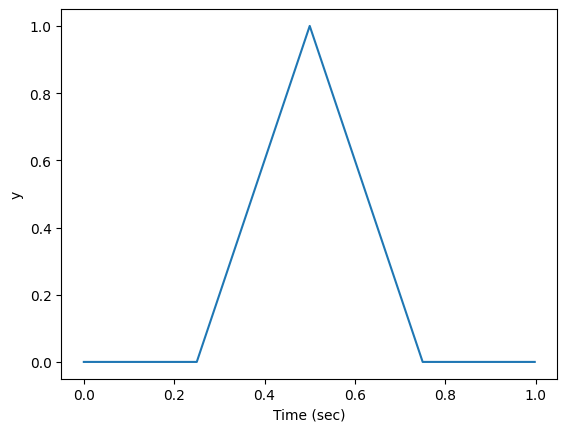

In [11]:
plt.plot(time, y)
plt.xlabel("Time (sec)")
plt.ylabel("y")

In [12]:
fft_y = np.fft.fft(y)
freq = np.fft.fftfreq(N, 1/f_s)

n = len(fft_y)
print(n)

print(fft_y[0])
print(np.sum(y))

512
(128+0j)
128.0


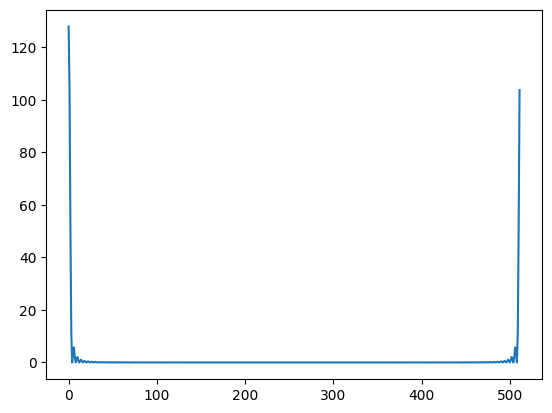

In [13]:
plt.plot(np.abs(fft_y))

In [14]:
fft_y_shifted = np.fft.fftshift(fft_y)
freq_shifted = np.fft.fftshift(freq)

Text(0.5, 1.0, 'Imaginary part')

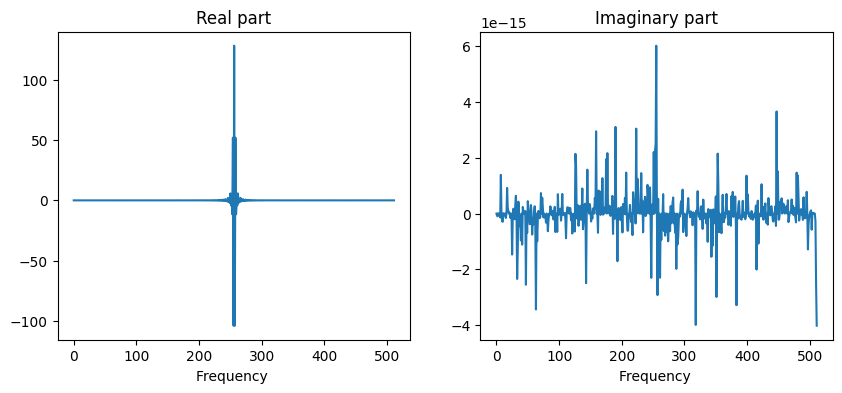

In [20]:
fft_y_shifted = np.fft.fftshift(fft_y)
freq_shifted = np.fft.fftshift(freq)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
#plt.plot(freq_shifted, np.real(fft_y_shifted)) 
plt.plot(np.real(fft_y_shifted))
plt.xlabel("Frequency ")
plt.title("Real part")
plt.subplot(1,2,2)
#plt.plot(freq_shifted, np.imag(fft_y_shifted)) 
plt.plot( np.imag(fft_y_shifted))
plt.xlabel("Frequency ")
plt.title("Imaginary part")

Text(0.5, 0, 'Frequency (Hz)')

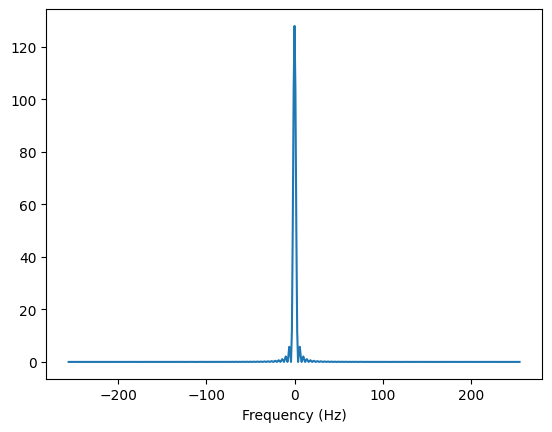

In [22]:
plt.plot(freq_shifted, np.abs(fft_y_shifted))
plt.xlabel("Frequency (Hz)")

Text(0.5, 1.0, 'IDFT')

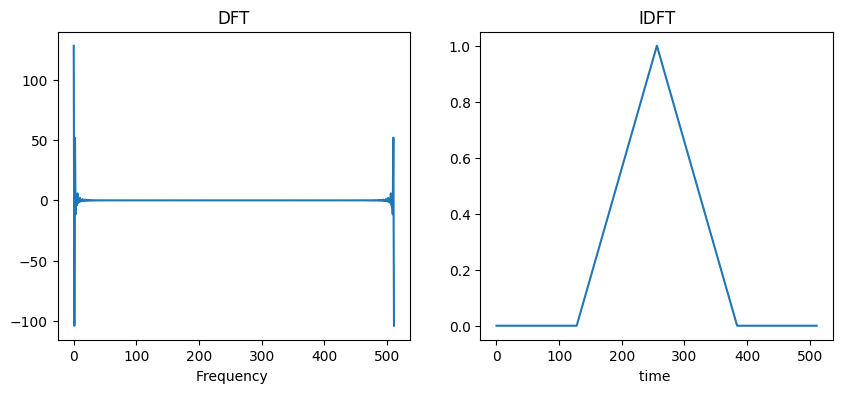

In [28]:

y_rec=np.fft.ifft(fft_y)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(np.real(fft_y)) 
#plt.plot(freq_shifted, np.real(np.fft.fftshift(fft_y)))
plt.xlabel("Frequency ")
plt.title("DFT")

plt.subplot(1,2,2)
plt.xlabel("time ")
plt.plot(y_rec.real) 
plt.title("IDFT")

Text(0.5, 1.0, 'IDFT')

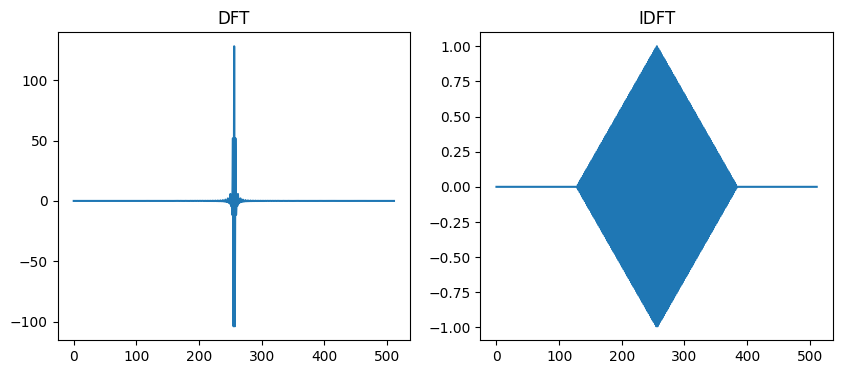

In [29]:
# Torniamo alla versione shiftata

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(np.real(fft_y_shifted)) 

plt.title("DFT")
plt.subplot(1,2,2)

plt.plot(np.fft.ifft(fft_y_shifted).real) 
plt.title("IDFT")

Text(0.5, 1.0, 'IDFT')

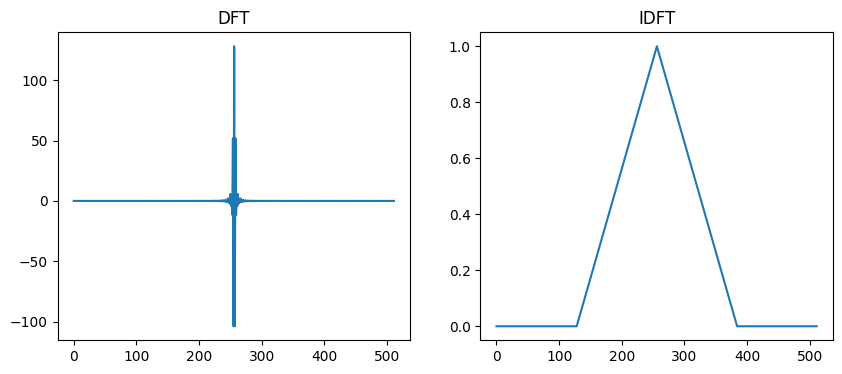

In [30]:
# inverse DFT
fft_y_shifted = np.fft.fftshift(fft_y)
y_rec=np.fft.ifft(np.fft.ifftshift(fft_y_shifted))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(np.real(fft_y_shifted)) 
#plt.xlabel("Frequency ")
plt.title("DFT")
plt.subplot(1,2,2)
#plt.xlabel("time ")
plt.plot(y_rec.real) 
plt.title("IDFT")